In [1]:
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = r"D:\Python_For_DataScience\Stat\assignment\nepal_student_performance.csv"
df = pd.read_csv(FILE_PATH)

num_cols = df.select_dtypes("number").columns.drop("student_id").tolist()
corr_matrix = df[num_cols].corr().round(3)
print(corr_matrix)

                  age  study_hours  sleep_hours  attendance_pct  \
age             1.000       -0.030       -0.037          -0.016   
study_hours    -0.030        1.000        0.035           0.000   
sleep_hours    -0.037        0.035        1.000          -0.005   
attendance_pct -0.016        0.000       -0.005           1.000   
family_income  -0.060       -0.051        0.057           0.003   
exam_score     -0.035        0.754        0.124           0.188   

                family_income  exam_score  
age                    -0.060      -0.035  
study_hours            -0.051       0.754  
sleep_hours             0.057       0.124  
attendance_pct          0.003       0.188  
family_income           1.000       0.019  
exam_score              0.019       1.000  


Correlation between study_hours and exam_score: r = 0.754


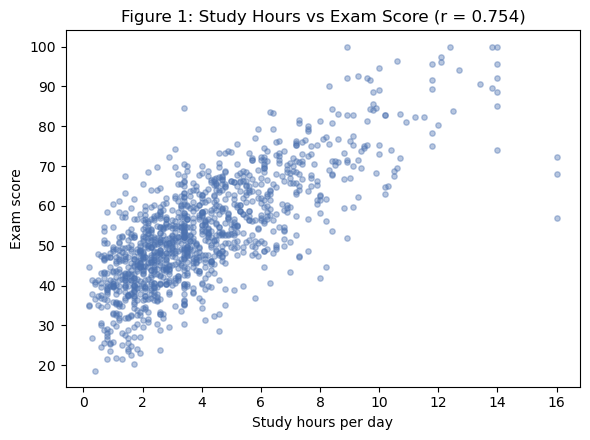

In [2]:
r = df["study_hours"].corr(df["exam_score"])
print("Correlation between study_hours and exam_score: r =", round(r, 3))

plt.figure(figsize=(6, 4.5))
plt.scatter(df["study_hours"], df["exam_score"], alpha=0.4, s=15, color="#4C72B0")
plt.title("Figure 1: Study Hours vs Exam Score (r = 0.754)")
plt.xlabel("Study hours per day")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

Weakest correlations (closest to zero):
study_hours     attendance_pct    0.000
attendance_pct  family_income     0.003
sleep_hours     attendance_pct   -0.005
age             attendance_pct   -0.016
family_income   exam_score        0.019
dtype: float64

Weakest pair: ('study_hours', 'attendance_pct') -> r = 0.0


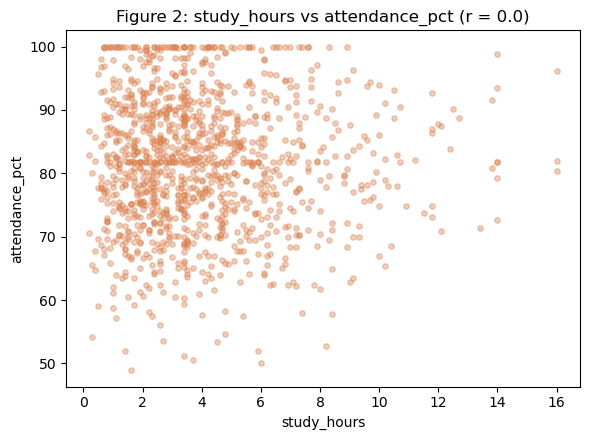

In [3]:
import numpy as np

c = corr_matrix.copy()
mask = np.triu(np.ones(c.shape), k=1).astype(bool)
pairs = c.where(mask).stack().sort_values(key=lambda s: s.abs())
print("Weakest correlations (closest to zero):")
print(pairs.head(5))

weakest_pair = pairs.index[0]   # the two variable names
print("\nWeakest pair:", weakest_pair, "-> r =", round(pairs.iloc[0], 4))

plt.figure(figsize=(6, 4.5))
plt.scatter(df[weakest_pair[0]], df[weakest_pair[1]], alpha=0.4, s=15, color="#DD8452")
plt.title(f"Figure 2: {weakest_pair[0]} vs {weakest_pair[1]} (r = {round(pairs.iloc[0], 4)})")
plt.xlabel(weakest_pair[0])
plt.ylabel(weakest_pair[1])
plt.tight_layout()
plt.show()

Regression equation: exam_score = 37.325 + 3.956 * study_hours
Slope (b1)     : 3.956
Intercept (b0) : 37.325
r              : 0.7544
R-squared      : 0.5691


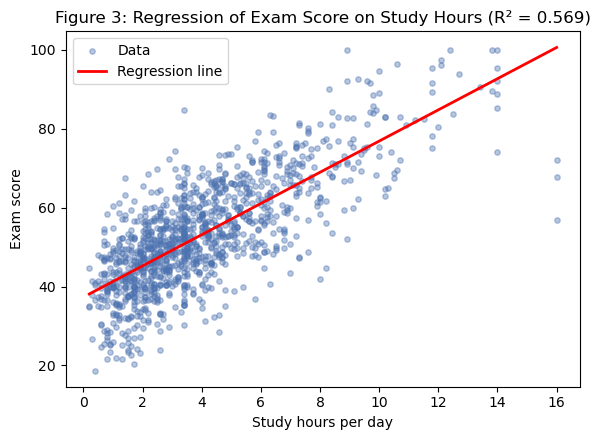

In [8]:
x = df["study_hours"]
y = df["exam_score"]

# regression coefficients (least squares)
b1 = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
b0 = y.mean() - b1 * x.mean()
r = x.corr(y)
r2 = r ** 2

print(f"Regression equation: exam_score = {b0:.3f} + {b1:.3f} * study_hours")
print(f"Slope (b1)     : {b1:.3f}")
print(f"Intercept (b0) : {b0:.3f}")
print(f"r              : {r:.4f}")
print(f"R-squared      : {r2:.4f}")

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, alpha=0.4, s=15, color="#4C72B0", label="Data")
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, color="red", linewidth=2, label="Regression line")
plt.title(f"Figure 3: Regression of Exam Score on Study Hours (R\u00b2 = {r2:.3f})")
plt.xlabel("Study hours per day")
plt.ylabel("Exam score")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import sys
!{sys.executable} -m pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    ----------------

In [12]:
import statsmodels.api as sm

X = sm.add_constant(x)   # x = study_hours from the earlier cell
model = sm.OLS(y, X).fit()   # y = exam_score

print(model.summary())

n = len(x)
resid = model.resid
ser = np.sqrt((resid ** 2).sum() / (n - 2))
print("\nStandard Error of the Regression (SER):", round(ser, 3))
print("Adjusted R-squared:", round(model.rsquared_adj, 4))
print("\nFirst 10 residuals:")
print(resid.head(10).round(3))

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     1582.
Date:                Wed, 30 Sep 2026   Prob (F-statistic):          3.07e-221
Time:                        20:09:20   Log-Likelihood:                -4340.5
No. Observations:                1200   AIC:                             8685.
Df Residuals:                    1198   BIC:                             8695.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          37.3250      0.475     78.600      